In [ ]:
#| default_exp isolation_forest

# Isolation Forest for Bridge SHM

> Anomaly detection on the KW51 railway bridge dataset using Isolation Forest


#### Importing the necessary libraries

```python
import pandas as pd
```
 importing pandas which helps in loading and visualising data set and manupulating dataset

In [1]:
import pandas as pd 

## Introduction

The KW51 railway bridge dataset was obtained from Maes and Lombaert, KU Leuven. 
It contains data collected over a 15-month monitoring campaign between 2018 and 2019, 
covering pre-damage, retrofitting, and post-repair periods.

Traditional bridge inspections are manual and not always reliable. Structural Health 
Monitoring (SHM) addresses this by installing sensors directly on the bridge that 
continuously record its behaviour. In our case, the sensors record 14 natural frequencies 
of the bridge along with environmental variables such as temperature, wind speed, and humidity.

When a bridge sustains damage, its natural frequencies shift. By detecting anomalies 
in these frequency readings, we can flag potential structural damage automatically 
without manual inspection.

In this notebook, we apply Isolation Forest — an unsupervised machine learning method 
— to detect these anomalies in the KW51 dataset.

In [2]:
df = pd.read_csv(r'E:\SHM_ML\data\cleaned\cleaned_data.csv', index_col=0) # loading data saved earlier 

In [3]:
df

,f3,f5,f6,f9,f10,f11,f12,f13,tBD31A,rhBD31A,tVL,rhVL,vpVL,raVL,wsVL,wdVL
timestamp,,,,,,,,,,,,,,,,
2018-10-01 00:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,10.100000,81.000000,10.825000,89.333336,1159.144738,0.0,9.40,293.00
2018-10-01 01:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,10.000000,85.000000,10.241667,92.750000,1157.524605,0.1,10.30,295.00
2018-10-01 02:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,9.900000,91.000000,10.150000,92.000000,1141.142430,0.0,10.40,284.00
2018-10-01 03:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,9.800000,89.000000,10.166666,91.083336,1131.033604,0.3,11.60,296.00
2018-10-01 04:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,9.800000,90.000000,9.558333,93.166664,1110.625906,0.2,9.60,283.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-01-15 19:00:00,1.888801,2.555565,2.986277,4.078602,4.386448,4.942893,5.440576,6.436793,9.641429,83.304917,8.386441,83.342373,918.137648,0.0,1.96,200.08
2020-01-15 20:00:00,1.887610,2.586921,2.982070,4.080208,4.386448,4.940309,5.426145,6.398893,9.143141,80.168936,7.545000,84.875000,882.549401,0.0,1.51,187.83
2020-01-15 21:00:00,1.886253,2.581889,2.987133,4.078480,4.386448,4.908271,5.432978,6.410531,8.795149,82.076947,6.301667,89.455000,853.705976,0.0,1.07,199.95


In [4]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest

# Create dummy data — 100 normal points clustered around 0
# and 5 obvious outliers far away
rng = np.random.seed(42)

normal = np.random.randn(100, 2)        # 100 rows, 2 features, clustered near 0
outliers = np.array([[10, 10],          # these 5 points are far from the cluster
                     [-10, -10],
                     [10, -10],
                     [-10, 10],
                     [8, 8]])

X = np.vstack([normal, outliers])       # stack them into one array, 105 rows total

# Build the model
model = IsolationForest(
    n_estimators=100,      # number of trees in the forest
    max_samples=50,        # how many points each tree is trained on
    contamination=0.05,    # we expect 5% of points to be anomalies (5 out of 105)
    random_state=42        # fixes randomness so results are reproducible
)

# Train the model — it learns what "normal" looks like
model.fit(X)

# Get anomaly scores for every point
# more negative = more anomalous in sklearn's convention
scores = model.score_samples(X)

# Get labels — sklearn returns -1 for anomaly, 1 for normal
labels = model.predict(X)

# Put it all together
results = pd.DataFrame(X, columns=['feature_1', 'feature_2'])
results['anomaly_score'] = scores
results['label'] = labels

print(results.tail(10))  # last 10 rows — should show our 5 outliers flagged

     feature_1  feature_2  anomaly_score  label
95   -0.446515   0.856399      -0.398170      1
96    0.214094  -1.245739      -0.407782      1
97    0.173181   0.385317      -0.366962      1
98   -0.883857   0.153725      -0.385960      1
99    0.058209  -1.142970      -0.398592      1
100  10.000000  10.000000      -0.766391     -1
101 -10.000000 -10.000000      -0.759764     -1
102  10.000000 -10.000000      -0.762370     -1
103 -10.000000  10.000000      -0.755891     -1
104   8.000000   8.000000      -0.748336     -1


In [5]:
print(pd.DataFrame(X, columns=['feature_1', 'feature_2']).head(10))

   feature_1  feature_2
0   0.496714  -0.138264
1   0.647689   1.523030
2  -0.234153  -0.234137
3   1.579213   0.767435
4  -0.469474   0.542560
5  -0.463418  -0.465730
6   0.241962  -1.913280
7  -1.724918  -0.562288
8  -1.012831   0.314247
9  -0.908024  -1.412304


In [6]:
df_normal = df['2018-10-01':'2019-04-30']

X = df_normal[["f3", "f5", "f6", "f9", "f10", "f11", "f12", "f13"]]
X.head()



,f3,f5,f6,f9,f10,f11,f12,f13
timestamp,,,,,,,,
2018-10-01 00:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306
2018-10-01 01:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306
2018-10-01 02:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306
2018-10-01 03:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306
2018-10-01 04:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306


In [7]:

print(X.shape)

(5064, 8)


In [8]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=100,    
    max_samples=256,     
    contamination=0.1,   
    random_state=42      
)

model.fit(X)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",256
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.1
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [9]:
X_full_freq = df[["f3", "f5", "f6", "f9", "f10", "f11", "f12", "f13"]]

# Get anomaly scores for every point
# more negative = more anomalous in sklearn's convention
scores = model.score_samples(X_full_freq)
print(scores)


[-0.37231947 -0.37231947 -0.37231947 ... -0.68006987 -0.69265924
 -0.70920119]


In [10]:
# Get labels — sklearn returns -1 for anomaly, 1 for normal
labels = model.predict(X_full_freq)

In [11]:
# Put it all together
results = pd.DataFrame(X_full_freq, columns=["f3", "f5", "f6", "f9", "f10", "f11", "f12", "f13"])
results['anomaly_score'] = scores
results['label'] = labels

In [12]:
results

,f3,f5,f6,f9,f10,f11,f12,f13,anomaly_score,label
timestamp,,,,,,,,,,
2018-10-01 00:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,-0.372319,1
2018-10-01 01:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,-0.372319,1
2018-10-01 02:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,-0.372319,1
2018-10-01 03:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,-0.372319,1
2018-10-01 04:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,-0.372319,1
...,...,...,...,...,...,...,...,...,...,...
2020-01-15 19:00:00,1.888801,2.555565,2.986277,4.078602,4.386448,4.942893,5.440576,6.436793,-0.713427,-1
2020-01-15 20:00:00,1.887610,2.586921,2.982070,4.080208,4.386448,4.940309,5.426145,6.398893,-0.678131,-1
2020-01-15 21:00:00,1.886253,2.581889,2.987133,4.078480,4.386448,4.908271,5.432978,6.410531,-0.680070,-1


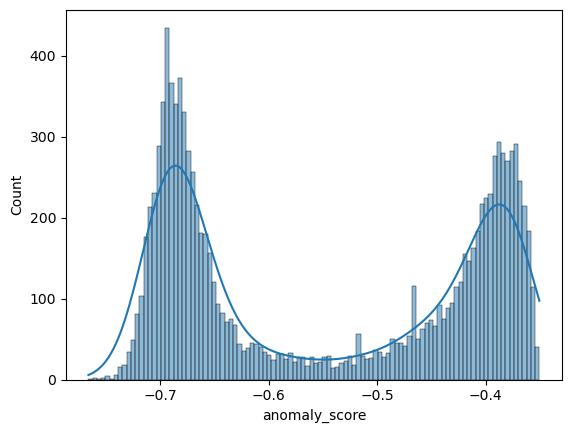

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt


scores = results['anomaly_score'] 

sns.histplot(scores, bins=106, kde=True)
plt.show()

In [14]:
print((results['anomaly_score'] < -0.55).sum())
print(len(results))

5821
11328


Okay so looking at the above histogram we see that it is a bimodal distribution, firstly we can see that the it is on the negative x axis which is just the convention of sk learn now moving on it looks like nearly half of the data is below -0.5 whic means that the model is flagging half of the data as anomalies which is not good but there is a reason as i understand for it, the environmental exogenous variables were not taken into consideration, since with the enviroment like temperature the naturual frequencies change and the model is flagging that changne as an anomaluy aswell  which will be taken care of below  

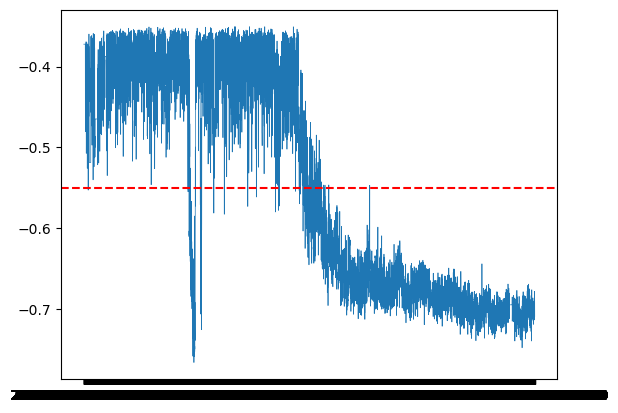

In [15]:
plt.plot(results.index, results['anomaly_score'], linewidth=0.5)
plt.axhline(y=-0.55, color='red', linestyle='--', label='threshold')
plt.show()

Alright so plot above is off the anomaly scores that we calculated and it is clearly visible hey value drops after around -0.55 and it stays below that for the rest of the time now that is actually the time. Where the retrofitting was done where the damage was and there is one more thing to notice and that is the value never goes above -0.55 after that and that is because after retrofitting the bridge the frequencies the natural frequencies change so now the new normal is something different than what it was before 

In [16]:
X_full_freq

,f3,f5,f6,f9,f10,f11,f12,f13
timestamp,,,,,,,,
2018-10-01 00:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306
2018-10-01 01:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306
2018-10-01 02:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306
2018-10-01 03:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306
2018-10-01 04:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306
...,...,...,...,...,...,...,...,...
2020-01-15 19:00:00,1.888801,2.555565,2.986277,4.078602,4.386448,4.942893,5.440576,6.436793
2020-01-15 20:00:00,1.887610,2.586921,2.982070,4.080208,4.386448,4.940309,5.426145,6.398893
2020-01-15 21:00:00,1.886253,2.581889,2.987133,4.078480,4.386448,4.908271,5.432978,6.410531


In [19]:
from sklearn.linear_model import LinearRegression

freq_cols = ["f3", "f5", "f6", "f9", "f10", "f11", "f12", "f13"]
env_cols = ["tBD31A", "rhBD31A", "tVL", "rhVL", "vpVL", "raVL", "wsVL", "wdVL"]

df_normal = df['2018-10-01':'2019-04-30']

# Environmental variables
env_train = df_normal[env_cols]
env_full = df[env_cols]

# Frequency targets for training — normal period only
X_train_freq = df_normal[freq_cols]

# Full frequency data for residual calculation
X_full_freq = df[freq_cols]

# Train one regression model per frequency using normal period data
models = {}
for freq in freq_cols:
    model_reg = LinearRegression()
    model_reg.fit(env_train, X_train_freq[freq])
    models[freq] = model_reg

# Predict expected frequencies for entire dataset and compute residuals
residuals = pd.DataFrame(index=df.index)
for freq in freq_cols:
    predicted = models[freq].predict(env_full)
    residuals[freq] = X_full_freq[freq] - predicted

In [20]:
residuals.head()


,f3,f5,f6,f9,f10,f11,f12,f13
timestamp,,,,,,,,
2018-10-01 00:00:00,-0.002384,0.010922,-0.002991,-0.003000,-0.005017,-0.033447,0.001274,-0.003689
2018-10-01 01:00:00,-0.002009,0.010912,-0.003032,-0.003032,-0.004975,-0.034366,0.001635,-0.002621
2018-10-01 02:00:00,-0.001527,0.011409,-0.003273,-0.002959,-0.005244,-0.035869,0.001092,-0.002829
2018-10-01 03:00:00,-0.000815,0.010957,-0.003060,-0.002686,-0.005116,-0.032029,0.001324,-0.002780
2018-10-01 04:00:00,-0.000833,0.011488,-0.003085,-0.002918,-0.005253,-0.035003,0.001854,-0.002424


In [21]:
# Train Isolation Forest on residuals from normal period only
residuals_normal = residuals.loc[df_normal.index]

model_corrected = IsolationForest(
    n_estimators=100,
    max_samples=256,
    contamination=0.1,
    random_state=42
)

model_corrected.fit(residuals_normal)

# Predict on full residuals
scores_corrected = model_corrected.score_samples(residuals)
labels_corrected = model_corrected.predict(residuals)

# Store results
results_corrected = residuals.copy()
results_corrected['anomaly_score'] = scores_corrected
results_corrected['label'] = labels_corrected

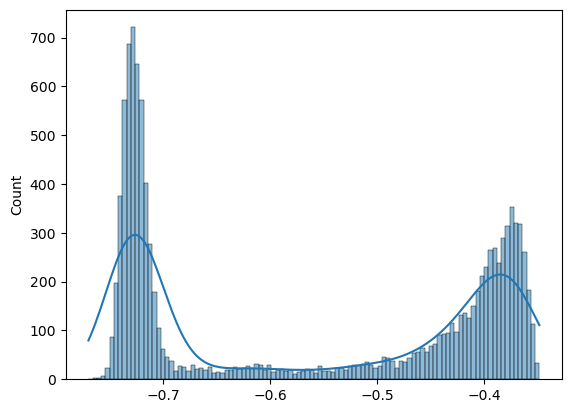

In [ ]:


sns.histplot(scores_corrected, bins=106, kde=True)
plt.show()

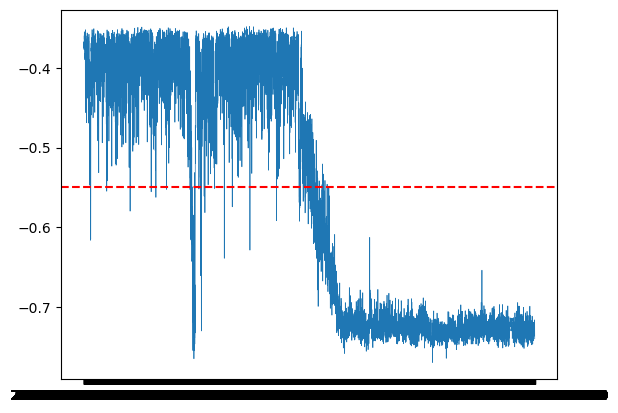

In [23]:
plt.plot(results_corrected.index, results_corrected['anomaly_score'], linewidth=0.5)
plt.axhline(y=-0.55, color='red', linestyle='--', label='threshold')
plt.show()

In [24]:
from sklearn.metrics import r2_score, mean_squared_error

for freq in freq_cols:
    predicted = models[freq].predict(env_train)
    actual = X_train_freq[freq]
    r2 = r2_score(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    print(f"{freq}: R² = {r2:.4f}, MSE = {mse:.6f}")

f3: R² = 0.0824, MSE = 0.000074
f5: R² = 0.0306, MSE = 0.000235
f6: R² = 0.4003, MSE = 0.000042
f9: R² = 0.4615, MSE = 0.000017
f10: R² = 0.3443, MSE = 0.000206
f11: R² = 0.0433, MSE = 0.001333
f12: R² = 0.2669, MSE = 0.000583
f13: R² = 0.4015, MSE = 0.001136


The R² values — the best one is f9 at 0.46, meaning even the best case linear regression only explains 46% of the frequency variation using environmental variables. For f3 and f5 it is explaining less than 10%.
This is poor. Linear regression is not capturing the relationship well at all.

It looks similar but there is one important difference — look at the pre-damage period on the left. In the first plot there was more variability, scores were dipping below -0.55 frequently during the normal period. In this plot the pre-damage period is slightly cleaner and sits more consistently above -0.55.